In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

diabetes_ds = load_diabetes()
df = pd.DataFrame(diabetes_ds.data, columns=diabetes_ds.feature_names)
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [22]:
X = df.select_dtypes(include=np.number)

In [23]:
X = X.dropna()

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
lables = dbscan.fit_predict(X_scaled)

In [26]:
n_clusters = len(set(lables)) - (1 if -1 in lables else 0)
n_noise = list(lables).count(-1)

In [27]:
if n_clusters > 1:
    score = silhouette_score(X_scaled, lables)
else:
    score = -1

In [28]:
results = []
params = [
    (0.3, 5),
    (0.5, 5),
    (0.7, 5),
    (0.5, 10)
]
for eps, min_samples in params:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    lables = db.fit_predict(X_scaled)
    n_clusters = len(set(lables)) - (1 if -1 in lables else 0)
    n_noise = list(lables).count(-1)

    if n_clusters > 1:
        score = silhouette_score(X_scaled, lables)
    else:
        score = -1

    results.append([eps, min_samples, n_clusters, n_noise, score])

results_df = pd.DataFrame(results, columns=["eps", "min_samples", "clusters", "noise", "score"])
results_df



,eps,min_samples,clusters,noise,score
0,0.3,5,0,442,-1
1,0.5,5,0,442,-1
2,0.7,5,0,442,-1
3,0.5,10,0,442,-1


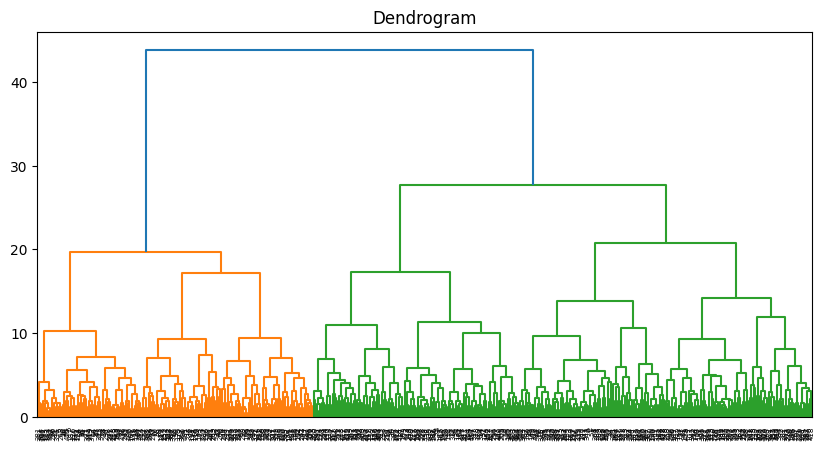

In [29]:
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

In [30]:
results_hc = []
for linkage_method in ['ward', 'complete']:
    for k in [2, 3, 4]:
        hc = AgglomerativeClustering(n_clusters=k, linkage=linkage_method)
        lables = hc.fit_predict(X_scaled)

        score = silhouette_score(X_scaled, lables)

        results_hc.append([linkage_method, k, score])

hc_df = pd.DataFrame(results_hc, columns=["linkage", "clusters", "score"])
hc_df

,linkage,clusters,score
0,ward,2,0.179950
1,ward,3,0.124965
2,ward,4,0.113048
3,complete,2,0.167129
4,complete,3,0.085243
5,complete,4,0.070043


In [31]:
## Different linkage methods produced different clustering quality because they measure distance 
# between clusters differently (e.g., ward minimizes variance, complete uses maximum distance)

In [32]:
print("DBSCAN results")
print(results_df)

print("\n Hierarchical Clustering Results:")
print(hc_df)

DBSCAN results
   eps  min_samples  clusters  noise  score
0  0.3            5         0    442     -1
1  0.5            5         0    442     -1
2  0.7            5         0    442     -1
3  0.5           10         0    442     -1

 Hierarchical Clustering Results:
    linkage  clusters     score
0      ward         2  0.179950
1      ward         3  0.124965
2      ward         4  0.113048
3  complete         2  0.167129
4  complete         3  0.085243
5  complete         4  0.070043
